In [ ]:
%pip uninstall -y dataproc-spark-connect
%pip install -q -U pyspark==3.5.0 huggingface_hub pyarrow pandas==2.2.3 matplotlib seaborn

Found existing installation: dataproc-spark-connect 1.1.0
Uninstalling dataproc-spark-connect-1.1.0:
  Successfully uninstalled dataproc-spark-connect-1.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.9/316.9 MB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.8/796.8 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 123.5 MB/s eta 0:00:00


## IMPORTS


In [ ]:
import shutil
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import snapshot_download
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.functions import avg
from pyspark.sql.functions import length
from collections import Counter
import re

## DATA LOCATION


In [ ]:

DATA_ROOT = Path(r"/content/cosmopedia_web_v1")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
print("Data location:", DATA_ROOT)



Data location: /content/cosmopedia_web_v1


## DISK CHECK


In [ ]:
total, used, free = shutil.disk_usage(str(DATA_ROOT))
print(f"Total: {total/(1024**3):.2f} GiB")
print(f"Used:  {used/(1024**3):.2f} GiB")
print(f"Free:  {free/(1024**3):.2f} GiB")

# Keep enough space for the downloaded working dataset plus Spark processing.
if free < 45 * (1024**3):
    raise RuntimeError(
        f"Only {free/(1024**3):.2f} GiB is free on {DATA_ROOT}. "
        "At least ~45 GiB free is recommended for this notebook."
    )


Total: 112.64 GiB
Used:  48.46 GiB
Free:  64.16 GiB


## DOWNLOAD ONLY web_samples_v1


In [ ]:
snapshot_path = snapshot_download(
    repo_id="HuggingFaceTB/cosmopedia",
    repo_type="dataset",
    allow_patterns=["data/web_samples_v1/*.parquet"],
    local_dir=str(DATA_ROOT),
    max_workers=1,
)
print("Downloaded to:", snapshot_path)



Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 139 files:   0%|          | 0/139 [00:00<?, ?it/s]

Downloaded to: /content/cosmopedia_web_v1


## VERIFY SIZE

For this project, we use Cosmopedia's public web_samples_v1 split. The public Hugging Face metadata lists it as  a download size of about 38.98 GB. The downloaded Parquet files are the working dataset, and the selected complete Parquet shards below form the ≥3 GiB processing dataset.


In [ ]:
PARQUET_DIR = DATA_ROOT / "data" / "web_samples_v1"
parquet_files = sorted(PARQUET_DIR.glob("*.parquet"))

if not parquet_files:
    raise FileNotFoundError(f"No Parquet files found in {PARQUET_DIR}")

working_bytes = sum(p.stat().st_size for p in parquet_files)
working_gib = working_bytes / (1024**3)

# Public Hugging Face metadata for web_samples_v1.
# download_size = 38,978,124,936 bytes (~38.98 GB)
# dataset_size  = 69,075,726,295 bytes (~69.08 GB)
RAW_DOWNLOAD_BYTES = 38_978_124_936
RAW_DATASET_BYTES = 69_075_726_295

print("Parquet files:", len(parquet_files))
print(f"Working dataset size on disk: {working_gib:.2f} GiB ({working_bytes/1e9:.2f} GB)")
print(f"Public web_samples_v1 download size: {RAW_DOWNLOAD_BYTES/1e9:.2f} GB")
print(f"Public web_samples_v1 dataset size:  {RAW_DATASET_BYTES/1e9:.2f} GB")

if working_bytes < 12 * (1024**3):
    raise RuntimeError(
        f"Working dataset is only {working_gib:.2f} GiB. "
        "The assignment requires at least 12 GiB of working data."
    )


Parquet files: 139
Working dataset size on disk: 36.30 GiB (38.98 GB)
Public web_samples_v1 download size: 38.98 GB
Public web_samples_v1 dataset size:  69.08 GB


## START SPARK


In [ ]:
spark = (
    SparkSession.builder
    .appName("Cosmopedia_MIT805")
    .master("local[2]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.files.maxPartitionBytes", "128m")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)



Spark: 3.5.0


## LOAD DATA


In [ ]:
DATA_PATH = str(DATA_ROOT / "data" / "web_samples_v1" / "*.parquet")

df = spark.read.parquet(DATA_PATH)

print("Columns:")
print(df.columns)

print("\nSchema:")
df.printSchema()


Columns:
['text_token_length', 'prompt', 'text', 'seed_data', 'format', 'audience']

Schema:
root
 |-- text_token_length: long (nullable = true)
 |-- prompt: string (nullable = true)
 |-- text: string (nullable = true)
 |-- seed_data: string (nullable = true)
 |-- format: string (nullable = true)
 |-- audience: string (nullable = true)



In [47]:
display(
    df.select(
        "text_token_length",
        "format",
        "audience",
        "seed_data",
        "text"
    ).limit(5).toPandas()
)

,text_token_length,format,audience,seed_data,text
0,993,textbook_academic_tone,college_students,web_samples_v1,Course Unit: The Art of Adaptation: Bringing ...
1,921,textbook_academic_tone,college_students,web_samples_v1,Course Unit: Transformation of Found Objects ...
2,916,blogpost,general,web_samples_v1,Title: Unlocking Connections: The Role of Onl...
3,1037,textbook_academic_tone,college_students,web_samples_v1,Course Unit: Artisanal Charcuterie Production...
4,1031,blogpost,general,web_samples_v1,Title: A Culinary Fusion Experience: Chilli P...


## RAW RECORD COUNT


In [ ]:
raw_row_count = df.count()
print(f"Working-dataset records: {raw_row_count:,}")


Working-dataset records: 12,426,348


## CREATING A PROCESSING DATASET THAAT IS ≥3 GiB


In [48]:
TARGET_PROCESSING_GIB = 3.5
GIB = 1024 ** 3

rng = __import__("random").Random(42)
shuffled_files = parquet_files.copy()
rng.shuffle(shuffled_files)

selected_files = []
selected_bytes = 0
for file_path in shuffled_files:
    selected_files.append(file_path)
    selected_bytes += file_path.stat().st_size
    if selected_bytes >= TARGET_PROCESSING_GIB * GIB:
        break

if selected_bytes < 3 * GIB:
    raise RuntimeError("Could not construct a processing dataset of at least 3 GiB.")

processing_paths = [str(p) for p in selected_files]
processing_df = spark.read.parquet(*processing_paths)
processing_row_count = processing_df.count()
processing_gib = selected_bytes / GIB

print(f"Selected processing files: {len(selected_files)}")
print(f"Processing dataset size: {processing_gib:.2f} GiB ({selected_bytes/1e9:.2f} GB)")
print(f"Processing records: {processing_row_count:,}")
print("Processing dataset satisfies the assignment requirement (≥3 GiB).")


Selected processing files: 14
Processing dataset size: 3.66 GiB (3.93 GB)
Processing records: 1,251,575
Processing dataset satisfies the assignment requirement (≥3 GiB).


## MISSING VALUES


In [ ]:
processing_df.select([
    F.sum(F.col(c).isNull().cast("long")).alias(c)
    for c in processing_df.columns
]).show(truncate=False)


+-----------------+------+----+---------+------+--------+
|text_token_length|prompt|text|seed_data|format|audience|
+-----------------+------+----+---------+------+--------+
|0                |0     |0   |0        |0     |0       |
+-----------------+------+----+---------+------+--------+



## DUPLICATES


In [ ]:
# Exact duplicate check on the processing dataset.
# if "text" in processing_df.columns:
#     distinct_text_count = processing_df.select("text").distinct().count()
#     print(f"Distinct documents: {distinct_text_count:,}")
#     print(f"Exact duplicate documents: {processing_row_count-distinct_text_count:,}")


## DESCRIPTIVE STATISTICS


In [ ]:
if "text_token_length" in processing_df.columns:
    processing_df.select("text_token_length").summary(
        "count", "mean", "stddev", "min", "25%", "50%", "75%", "max"
    ).show()


+-------+-----------------+
|summary|text_token_length|
+-------+-----------------+
|  count|          1251575|
|   mean| 842.726136268302|
| stddev|283.3198141054501|
|    min|              150|
|    25%|              691|
|    50%|              806|
|    75%|              970|
|    max|             2511|
+-------+-----------------+



## CATEGORICAL EDA


In [ ]:
for column in ["seed_data", "format", "audience", "prompt_type"]:
    if column in processing_df.columns:
        print(f"\nTop values: {column}")
        processing_df.groupBy(column).count().orderBy(F.desc("count")).limit(20).show(truncate=False)



Top values: seed_data
+--------------+-------+
|seed_data     |count  |
+--------------+-------+
|web_samples_v1|1251575|
+--------------+-------+


Top values: format
+-----------------------+------+
|format                 |count |
+-----------------------+------+
|textbook_academic_tone |595770|
|blogpost               |549835|
|wikihow                |53094 |
|textbook_narrative_tone|52876 |
+-----------------------+------+


Top values: audience
+----------------+------+
|audience        |count |
+----------------+------+
|general         |655805|
|college_students|595770|
+----------------+------+



## SAFE SAMPLE FOR PLOTS


In [32]:
sample_pd = (
    processing_df
    .select("text", "text_token_length", "format", "audience")
    .sample(withReplacement=False, fraction=0.01, seed=42)
    .limit(100_000)
    .toPandas()
)
print("Small Pandas plot sample:", len(sample_pd))


Small Pandas plot sample: 12675


## TOKEN LENGTH


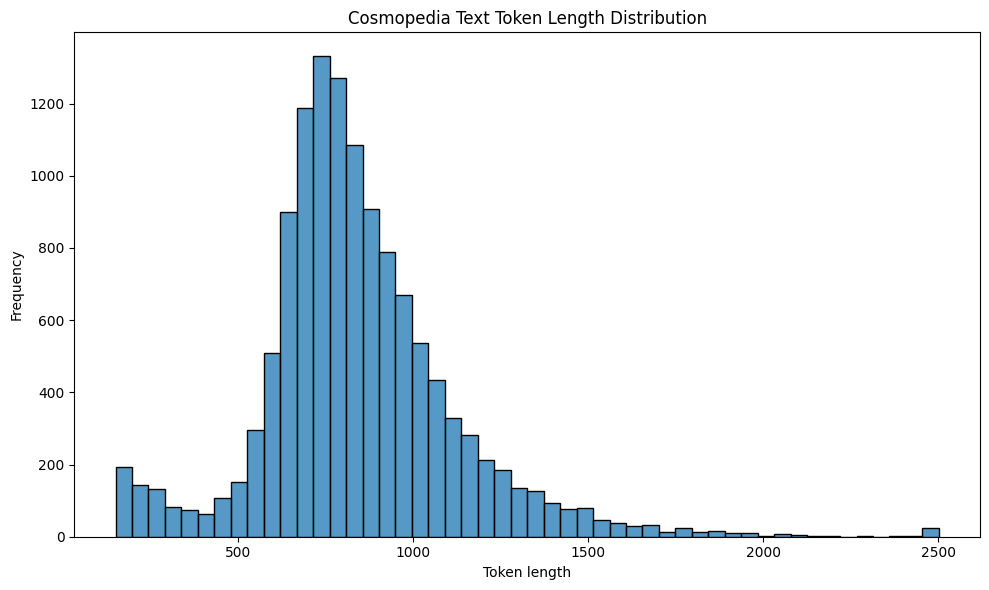

In [33]:
if "text_token_length" in sample_pd.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(sample_pd["text_token_length"].dropna(), bins=50)
    plt.title("Cosmopedia Text Token Length Distribution")
    plt.xlabel("Token length")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()



## FORMAT


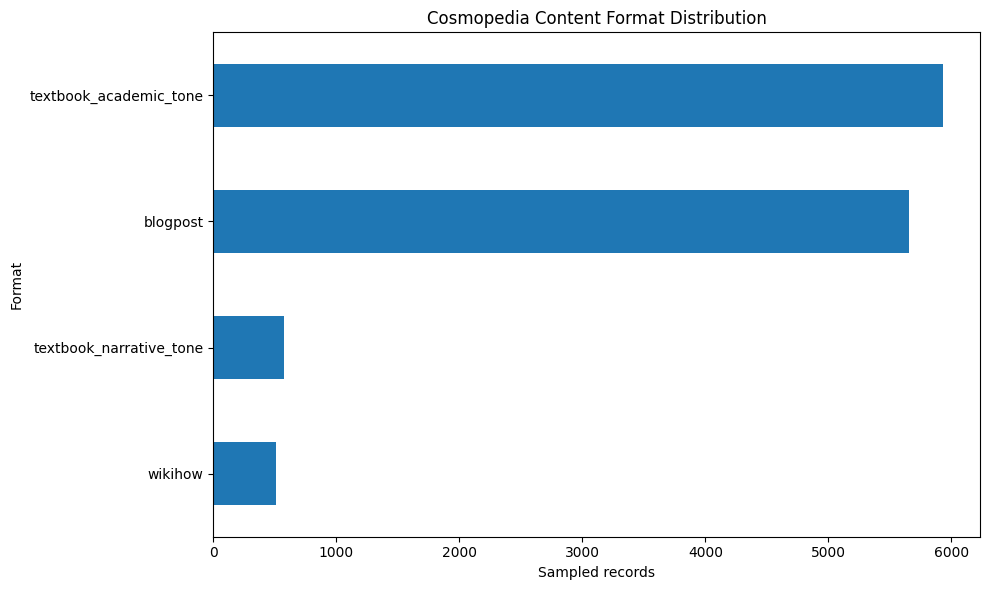

In [34]:
if "format" in sample_pd.columns:
    counts = sample_pd["format"].value_counts().head(15).sort_values()
    plt.figure(figsize=(10, 6))
    counts.plot(kind="barh")
    plt.title("Cosmopedia Content Format Distribution")
    plt.xlabel("Sampled records")
    plt.ylabel("Format")
    plt.tight_layout()
    plt.show()



In [35]:
processing_df.groupBy("format") \
  .agg(avg("text_token_length").alias("avg_length")) \
  .orderBy("avg_length", ascending=False) \
  .show()


+--------------------+-----------------+
|              format|       avg_length|
+--------------------+-----------------+
|textbook_narrativ...|969.3253271805734|
|textbook_academic...|922.4112577001192|
|             wikihow|869.5988058914378|
|            blogpost|741.6142733729209|
+--------------------+-----------------+



## AUDIENCE


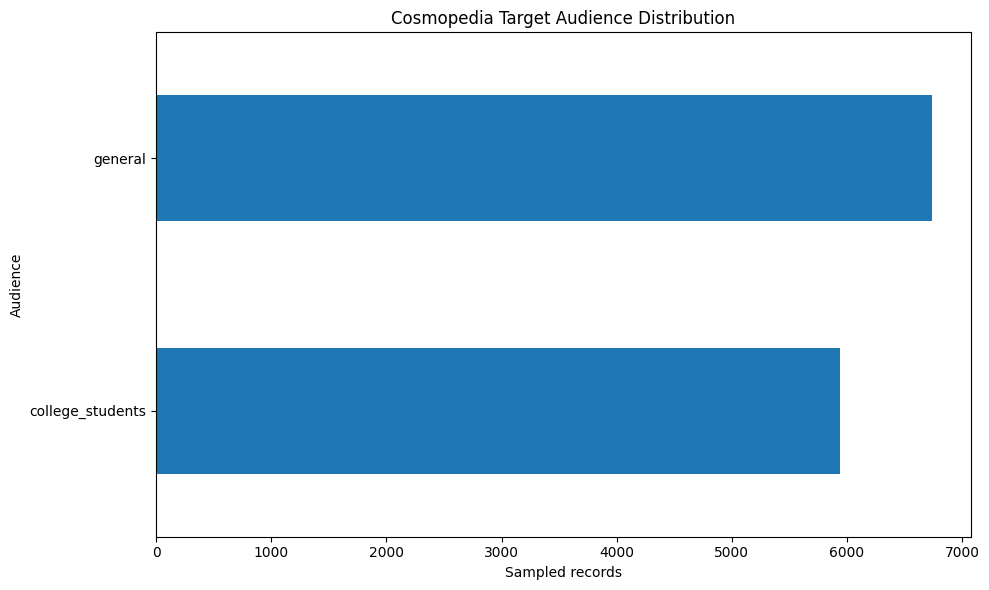

In [36]:
if "audience" in sample_pd.columns:
    counts = sample_pd["audience"].value_counts().head(15).sort_values()
    plt.figure(figsize=(10, 6))
    counts.plot(kind="barh")
    plt.title("Cosmopedia Target Audience Distribution")
    plt.xlabel("Sampled records")
    plt.ylabel("Audience")
    plt.tight_layout()
    plt.show()



In [37]:
processing_df.groupBy("audience") \
  .agg(avg("text_token_length").alias("avg_length")) \
  .show()


+----------------+-----------------+
|        audience|       avg_length|
+----------------+-----------------+
|         general|770.3357080229641|
|college_students|922.4112577001192|
+----------------+-----------------+



## CROSS TAB ANALYSIS

In [38]:
processing_df.groupBy(
    "format",
    "audience"
).count().show()


+--------------------+----------------+------+
|              format|        audience| count|
+--------------------+----------------+------+
|            blogpost|         general|549835|
|             wikihow|         general| 53094|
|textbook_academic...|college_students|595770|
|textbook_narrativ...|         general| 52876|
+--------------------+----------------+------+



## OUTLIER ANALYSIS

In [39]:
processing_df.orderBy(
    "text_token_length",
    ascending=False
).select(
    "text_token_length",
    "format",
    "audience"
).show(20, truncate=False)


+-----------------+----------------------+----------------+
|text_token_length|format                |audience        |
+-----------------+----------------------+----------------+
|2511             |textbook_academic_tone|college_students|
|2510             |textbook_academic_tone|college_students|
|2506             |textbook_academic_tone|college_students|
|2505             |textbook_academic_tone|college_students|
|2504             |textbook_academic_tone|college_students|
|2503             |textbook_academic_tone|college_students|
|2503             |textbook_academic_tone|college_students|
|2503             |textbook_academic_tone|college_students|
|2503             |textbook_academic_tone|college_students|
|2503             |textbook_academic_tone|college_students|
|2503             |textbook_academic_tone|college_students|
|2503             |textbook_academic_tone|college_students|
|2503             |textbook_academic_tone|college_students|
|2503             |textbook_academic_ton

## NLP

NLP exploration uses only a small Pandas sample from the Spark processing dataset. The full processing dataset remains in PySpark.


In [40]:
processing_df = processing_df.withColumn(
    "char_length",
    length("text")
)


In [41]:
processing_df.select("char_length").summary().show()


+-------+------------------+
|summary|       char_length|
+-------+------------------+
|  count|           1251575|
|   mean|3997.2560573677165|
| stddev|1372.6685000556927|
|    min|               457|
|    25%|              3248|
|    50%|              3866|
|    75%|              4659|
|    max|             17163|
+-------+------------------+



In [42]:
sample_text = (
    processing_df
    .select("text")
    .sample(withReplacement=False, fraction=0.01, seed=42)
    .limit(100_000)
    .toPandas()
)
print(f"NLP Pandas sample: {len(sample_text):,} records")


NLP Pandas sample: 12,675 records


## EXPORT RESULTS


In [43]:
RESULTS_ROOT = DATA_ROOT / "results"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

sample_pd.to_csv(RESULTS_ROOT / "eda_sample.csv", index=False)

with open(RESULTS_ROOT / "dataset_sizes.txt", "w", encoding="utf-8") as f:
    f.write(f"Raw public download size (web_samples_v1): {RAW_DOWNLOAD_BYTES/1e9:.2f} GB\n")
    f.write(f"Raw public dataset size (web_samples_v1): {RAW_DATASET_BYTES/1e9:.2f} GB\n")
    f.write(f"Working dataset size on disk: {working_bytes/1e9:.2f} GB\n")
    f.write(f"Working records: {raw_row_count:,}\n")
    f.write(f"Processing dataset size: {selected_bytes/1e9:.2f} GB\n")
    f.write(f"Processing records: {processing_row_count:,}\n")

print("Results saved to:", RESULTS_ROOT)


Results saved to: /content/cosmopedia_web_v1/results


In [44]:
all_text = " ".join(sample_text["text"].astype(str))

In [45]:
all_text = all_text.lower()

words = re.findall(r'\b[a-z]+\b', all_text)

word_counts = Counter(words)

In [46]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

words = [w for w in words if w not in stop_words]

Counter(words).most_common(20)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[('like', 15913),
 ('b', 15495),
 ('unit', 14045),
 ('understanding', 12922),
 ('course', 12234),
 ('c', 11762),
 ('one', 11294),
 ('various', 10032),
 ('key', 9315),
 ('data', 9238),
 ('development', 9199),
 ('potential', 9179),
 ('world', 8972),
 ('let', 8913),
 ('time', 8846),
 ('conclusion', 8843),
 ('introduction', 8836),
 ('strategies', 8757),
 ('personal', 7974),
 ('role', 7827)]